## PennyLane demo

This notebook demonstrates interfacing the parallelizer from PennyLane for computing expectation
values in parallel! The example is primitive, but the concepts apply to other uses cases too.

### Required modules

We'll use IQM fake backends for running jobs, so we import the 20-qubit simulator below. Obviously
we also need PennyLane, as well as some utilities.

In [1]:
from iqm.qiskit_iqm.fake_backends.fake_apollo import IQMFakeApollo
import pennylane as qml
import numpy as np
import functools
import random
random.seed(1)

print("Pennylane", qml.version())

Pennylane 0.45.0


Then we'll need the parallelizer itself! We additionally import `packers` for ensuring efficient use
of the backend. If this sounds unfamiliar, see [the packers notebook](./circuit-packers.ipynb).

In [2]:
from qc_parallelizer import Parallelizer, packers

### Backend instantiation

First, we instantiate the actual 20-qubit simulator backend.

In [3]:
backend = IQMFakeApollo()

Then we construct a parallelized backend from it. To ensure efficient use of resources, we supply
two things:
- `optimization_level=3` as part of the translation keyword arguments, which translates circuits
  (ideally) most optimially; and
- the minimizing VF2-based packer, which can be slower at finding circuit layouts, but should find
  the optimal packing at this scale.

Once the parallelizer is initialized, we build the parallelized backend with the `.across()` call.
Here we supply the backends we want to use (just one in this case), as well as the `sync_wait`
argument.

The `sync_wait` argument defines a delay, in seconds, that the parallelizer waits before actually
retrieving job results. In multithreaded applications, this gives the parallelizer a longer window
to gather circuits into more optimal combinations before submitting them. Without the delay, naive
code that does something like `result = backend.run(circuit).result()` would not parallelize at all.

The choice of value is a trade-off: too short, and there's no chance of parallelization; too long,
and you let the parallelizer (and backend) sit idle. Here, we set it to 0.5 seconds, which seems to
work well for this case. For general use with PennyLane, up to 2.0 might be necessary.
Experimentation is recommended!

In [4]:
par_backend = Parallelizer(
    translation_kwargs=dict(optimization_level=3),
    packer=packers.vf2.Minimizing(),
).across(backend, sync_wait=0.5)

Now, to the magic: the backend can be converted into a PennyLane device with the following property:

In [5]:
par_device = par_backend.as_pennylane_device

This device can be supplied in place of a regular PennyLane device, but job execution is
automatically parallelized!

### Circuit and expectation values

Now, let's define some work for the backend. We will use a 4-qubit circuit with `RX(pi/8)` gates on
all qubits, followed by a cascading chain of CNOTs. We will then measure expectation values of 16
random Pauli strings at the end.

In [6]:
n = 4

operators = []
for _ in range(16):
    ops = [random.choice((qml.X, qml.Y, qml.Z)) for _ in range(n)]
    operators.append(ops)

def circuit():
    for i in range(n):
        qml.RX(np.pi / 8, 0)
    for i in range(n - 1):
        qml.CNOT([i, i + 1])
    return [
        qml.expval(functools.reduce(
            lambda a, b: a @ b,
            (op(i) for i, op in enumerate(oper))
        ))
        for oper in operators
    ]

### Execution

To obtain a reference answer, we'll first estimate the expectation values with the regular backend
supplied to PennyLane as the standard `"qiskit.remote"` adapter device. To keep execution time
reasonable, we'll use 512 shots.

In [7]:
regular_device = qml.device("qiskit.remote", wires=20, backend=backend, optimization_level=3)
reference = qml.qnode(regular_device)(circuit, shots=512)()

Then, we'll do the same, but pass the parallelized device instead.

In [8]:
parallelized = qml.qnode(par_device)(circuit, shots=512)()

### Error analysis

Let's plot both results from above for visual comparison.

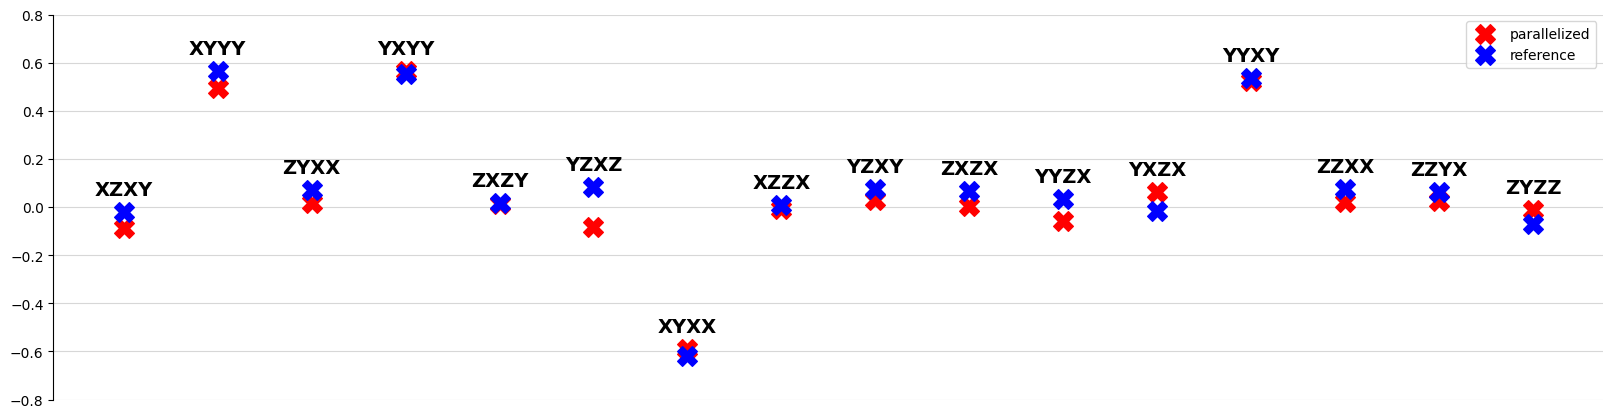

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))
ax.scatter(range(len(parallelized)), parallelized, s=200, c="red", marker="X", zorder=10, label="parallelized")
ax.scatter(range(len(reference)), reference, s=200, c="blue", marker="X", zorder=10, label="reference")

for i, ops in enumerate(operators):
    label = "".join(op(0).name[-1] for op in ops)
    height = max(parallelized[i], reference[i])
    ax.annotate(label, (i, height + 0.07), size=14, weight="bold", ha="center", zorder=11)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_ylim(-0.8, 0.8)
ax.grid(axis="y", alpha=0.5)
_ = ax.legend()

Given the noise that the simulator also implements, this looks fairly good! At the very least it
indicates that there is no internal confusion or mix-up happening in the whole
PennyLane-parallelizer-Qiskit pipeline.

### Parallelization

Let's look at how the executions were actually parallelized. For this, we can use the
`.timeline` property that the parallelized backend exposes, as well as the convenient plotting
function in the `visualization` package.

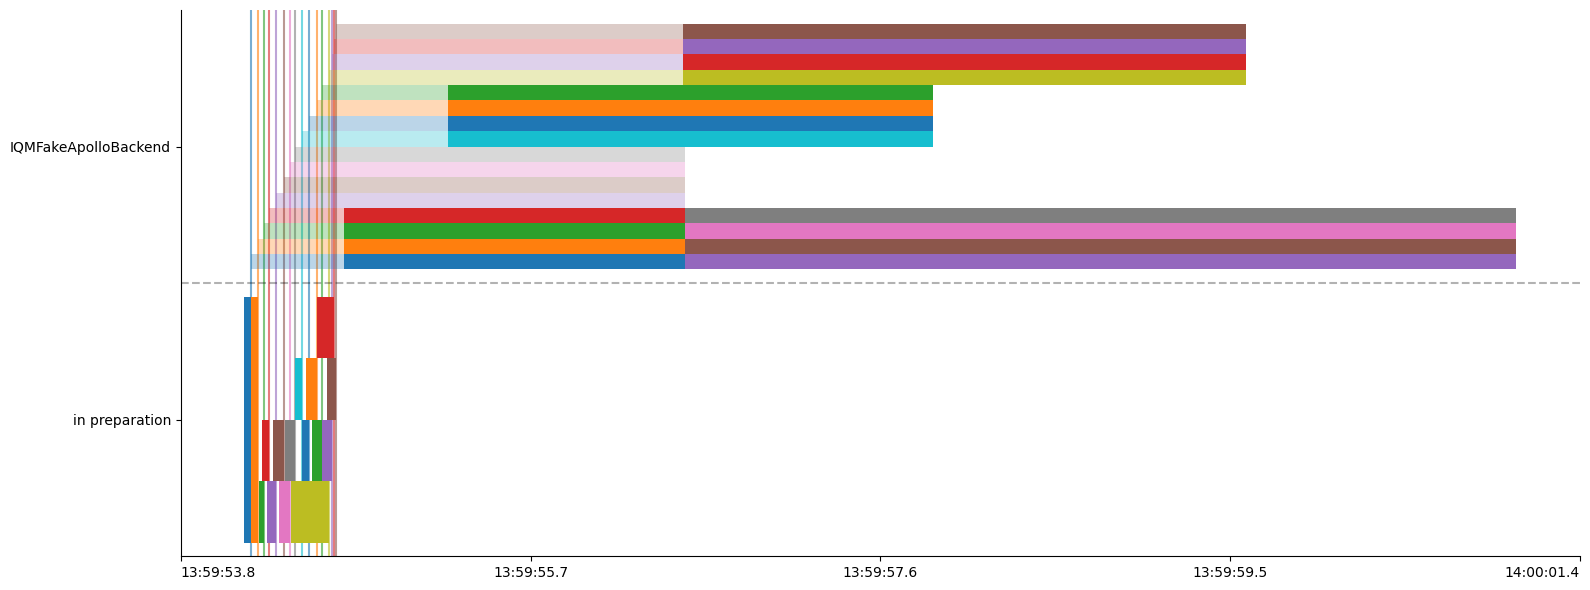

In [10]:
from qc_parallelizer.util import visualization

visualization.plot_timeline(par_backend.timeline, collapse_ratio=None)

Looks pretty good. There's a big preparation block in the beginning, followed by four batches of
four circuits being executed in parallel. (Note that only blocks of jobs that start and end at the
same time are actually parallelized. Otherwise overlapping blocks are either queuing or being
executed by another thread/process behind the simulator.)

Let's see this in numbers:

In [11]:
num_jobs = par_backend.backend_utilization[backend]
print(f"{num_jobs} job(s) submitted")

4 job(s) submitted


With just four jobs, we executed in total...

In [12]:
num_circuits = sum(len(batch) for batch in par_backend.history)
print(f"{num_circuits} circuit(s)")

16 circuit(s)


...which means that we achieved...

In [13]:
print(f"--> {num_circuits / num_jobs:.1f}x parallelization ratio!")

--> 4.0x parallelization ratio!


Not bad!

Obviously for local simulators, this is highly inefficient as opposed to running the circuits
independently. However, this demonstration used a simulator with "just" 20 qubits because it is
still reasonable to simulate locally&mdash;even better parallelization can be achieved with more
qubits, but the parallelized circuits get _much_ heavier to simulate!

#### Layout visualization

Finally, let's see how the circuits were laid out onto the backend. Since PennyLane submits them
to the parallelizer individually, we need to employ some trickery to plot them together.

We can retrieve the jobs from the backend's history. These jobs are actually job batches, but with
just one job in each. Job batches define an overload for the _bitwise or_ operator (`|`) that merges
job batches into one, so we'll use that to reduce/fold them all down to a single job batch that can
be visualized at once.

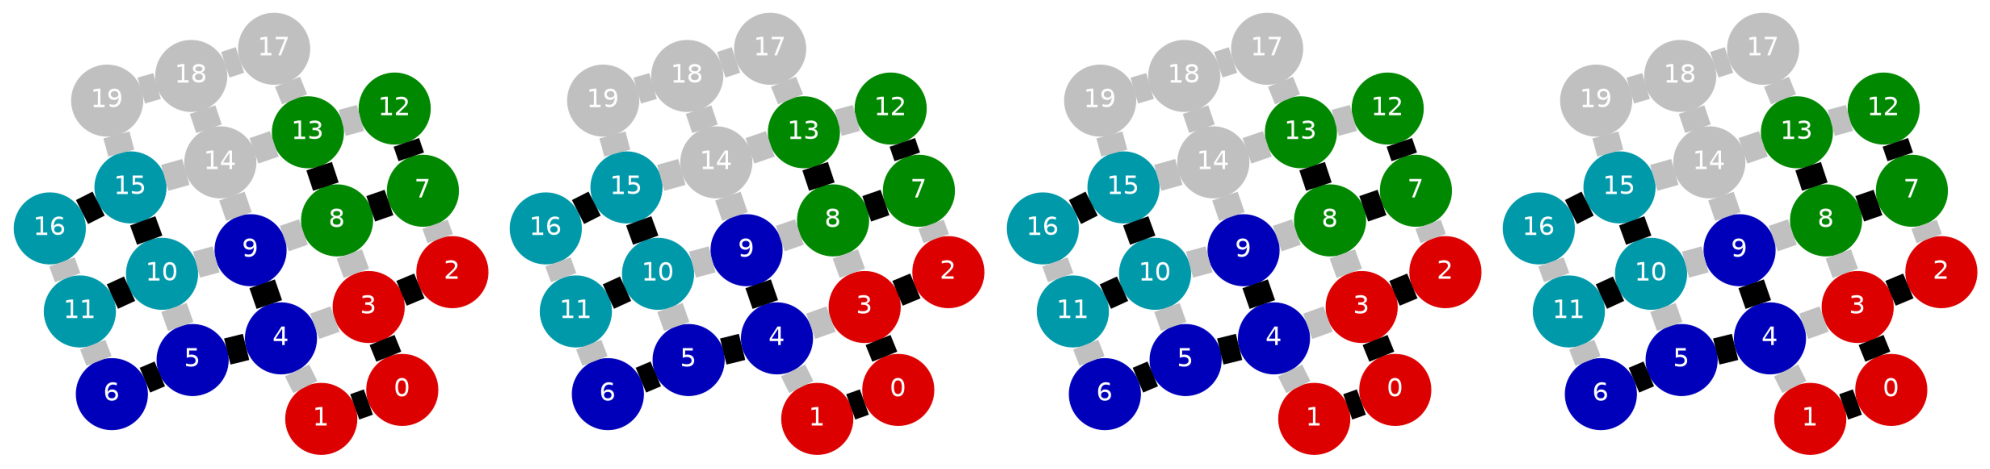

In [14]:
visualization.plot_job_batch(
    functools.reduce(lambda a, b: a | b, par_backend.history),
    figsize=(20, 8),
)

As expected, this is a very dense packing of four circuits with linear topology. A fifth circuit of
the same topology cannot be placed anywhere, which limits the jobs to at most four circuits at a
time.